In [1]:
import os
os.environ['USE_PYGEOS'] = '0'

import rasteroverview
import qtree
import morton
import dataservice.query

import numpy
import geopandas as gpd
import pandas as pd
import pyarrow.compute
import shapely.geometry
import datetime
import requests
import json
import geojson
import logging
from time import time
from tqdm import tqdm
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm

In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
with Path('/data/mfreitag/software/ibmpairspass.txt').open() as fp:
    geodn_auth = tuple(fp.read().strip().split(':')[1:])

In [4]:
overviewstore_directory_cropscape = '/data/raster/overviews3/'
dset_id_cropscape = '11' # Historical crop planting map (USA)
layer_id_cropscape = '111' # Cropscape (categorical)
pixel_level_cropscape = 21 #30m

In [5]:
overviewstore_directory_era5 = '/data/raster/overviews/'
dset_id_era5 = '190' # ERA5
layer_id_era5 = '49459' # ERA5 precipitation
pixel_level_era5 = 12 # ERA5

In [6]:
year = 2021

## Overview accelerated

In [7]:
benchmark = time()

In [8]:
# Instantiate rasteroverview objects and read in their metadata.
raster_cropscape = rasteroverview.Rasteroverview(
    dset_id=dset_id_cropscape, 
    layer_id=layer_id_cropscape,
    pixel_level=pixel_level_cropscape, 
    overviewstore_directory=overviewstore_directory_cropscape,
)

# Read the metadata
raster_cropscape.from_json()

raster_era5 = rasteroverview.Rasteroverview(
    dset_id=dset_id_era5, 
    layer_id=layer_id_era5,
    pixel_level=pixel_level_era5, 
    overviewstore_directory=overviewstore_directory_era5,
)

# Read the metadata
raster_era5.from_json()

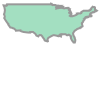

In [9]:
# Define the area of interest
api_response = requests.get(
    'https://pairs.res.ibm.com/ws/queryaois/geojson/24',
    auth=geodn_auth
)
query_polygon = shapely.geometry.shape(
    geojson.loads(
        api_response.text.rstrip()[1:-1].replace('""', '"')
    )
)
query_polygon

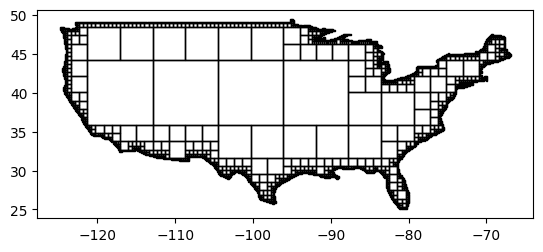

In [10]:
# Calculate the quadtree representation of the polygon
max_level = pixel_level_era5
qt = qtree.QTree(query_polygon, max_level)
qt.quadtree_dfs()
qt.to_geodataframe(filter_attr='is_qualified_leaf').plot(color='none', aspect='equal')
plt.show()

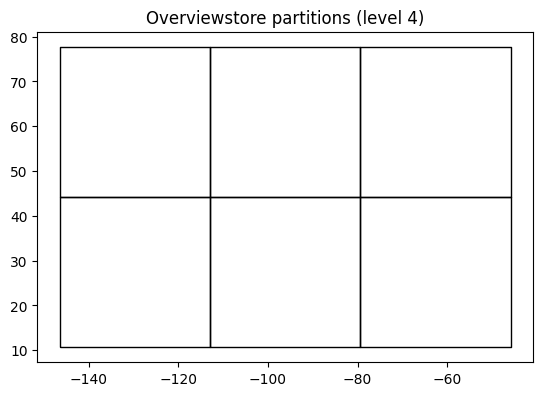

,q_key,geometry
0,0q0023,"POLYGON ((-146.44557 10.66330, -146.44557 44.2..."
1,0q0032,"POLYGON ((-112.89114 10.66330, -112.89114 44.2..."
2,0q0033,"POLYGON ((-79.33670 10.66330, -79.33670 44.217..."
3,0q0201,"POLYGON ((-146.44557 44.21773, -146.44557 77.7..."
4,0q0210,"POLYGON ((-112.89114 44.21773, -112.89114 77.7..."
5,0q0211,"POLYGON ((-79.33670 44.21773, -79.33670 77.772..."


In [11]:
# Get the landuse spatial partitions 
max_level_cropscape = raster_cropscape.spatial_level
qt_cropscape = qtree.QTree(query_polygon, max_level_cropscape)
gdf_partitions_cropscape = qt_cropscape.gridded_to_geodataframe(key_col=None, level_col=None)
gdf_partitions_cropscape.plot(color='none', aspect='equal')
plt.title(f'Overviewstore partitions (level {max_level_cropscape})')
plt.show()
gdf_partitions_cropscape

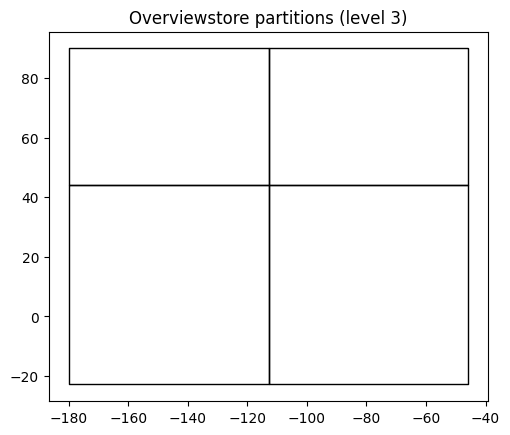

,q_key,geometry
0,0q002,"POLYGON ((-180.00000 44.21773, -112.89114 44.2..."
1,0q003,"POLYGON ((-112.89114 -22.89114, -112.89114 44...."
2,0q020,"POLYGON ((-112.89114 90.00000, -112.89114 44.2..."
3,0q021,"POLYGON ((-45.78227 90.00000, -45.78227 44.217..."


In [12]:
# Get the ERA5 spatial partitions 
max_level_era5 = raster_era5.spatial_level
qt_era5 = qtree.QTree(query_polygon, max_level_era5)
gdf_partitions_era5 = qt_era5.gridded_to_geodataframe(key_col=None, level_col=None)
gdf_partitions_era5.plot(color='none', aspect='equal')
plt.title(f'Overviewstore partitions (level {max_level_era5})')
plt.show()
gdf_partitions_era5

In [13]:
# Temporal partition
temporal_partition = f'y{year}'

In [14]:
# Define the columns we grab from the parquet file
# (Cropscape data is categorical. count_111 is histogram column for class 111 (aquatic landuse))
columns_cropscape = ['q_key', 'timestamp', 'geometry', 'count_111']

In [15]:
print(time() - benchmark)

6.8002660274505615


In [16]:
# Read the cropscape overviews from parquet
gdf_cropscape = []
for spatial_partition in tqdm(gdf_partitions_cropscape['q_key'], total=gdf_partitions_cropscape.shape[0]):
    gdf_cropscape.append(
        gpd.read_parquet(
            raster_cropscape._filepath(spatial_partition, temporal_partition),
            columns=columns_cropscape,
            filters=[
                ('count_111', '>', 0)
            ]
        )
    )
gdf_cropscape = pd.concat(gdf_cropscape, axis=0)
gdf_cropscape.reset_index(drop=True, inplace=True)

gdf_cropscape['q_key_era5_pixel'] = gdf_cropscape['q_key'].str[:-4]
gdf_cropscape['q_key_era5_overview'] = gdf_cropscape['q_key'].str[:-9]
gdf_cropscape['q_key_era5_partition'] = gdf_cropscape['q_key'].str[:-13]

100%|████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.66s/it]


In [17]:
print(time() - benchmark)

19.324316263198853


In [18]:
# Define the columns we grab from the parquet file
# (ERA5 precipitation is numeric data and thus we may get min, mean, max statistics)
columns_era5 = ['q_key', 'timestamp', 'geometry', 'min', 'mean', 'max']

In [19]:
# Define the precipitation threshold
precip_threshold = 0.025

In [20]:
print(time() - benchmark)

19.775309562683105


In [21]:
# Read the ERA5 precipitation overviews from parquet
select_areas = []
for spatial_partition_era5 in gdf_cropscape['q_key_era5_partition'].drop_duplicates():
    gdf_era5 = gpd.read_parquet(
        raster_era5._filepath(spatial_partition_era5, temporal_partition),
        columns=columns_era5,
        filters=[
            ('max', '>', precip_threshold),
            ('q_key', 'in', gdf_cropscape['q_key_era5_overview'].drop_duplicates().tolist())
        ]
    )
    logging.info(gdf_era5.shape[0])
    if gdf_era5.shape[0] > 0:
        select_areas.append(gdf_era5)
select_areas = pd.concat(select_areas, axis=0)
select_areas = select_areas.set_index(['q_key', 'timestamp']).sort_index()

INFO:root:0
INFO:root:47
INFO:root:0
INFO:root:0


In [22]:
print(time() - benchmark)

20.75518250465393


In [23]:
epsilon = 1e-9

In [24]:
# Now we query the raw ERA5 data for the areas/timestamps we determined using the MAX overview statistics
result = []

for q_key in tqdm(
    select_areas.index.get_level_values('q_key').drop_duplicates(),
    total=select_areas.index.get_level_values('q_key').drop_duplicates().shape[0]
):
    query_info = select_areas.loc[q_key]
    
    timestamps = (
        (query_info.index - pd.Timestamp('1970-01-01T00:00:00')) / pd.Timedelta('1s')
    ).astype(numpy.int64)
    query_bounds = query_info['geometry'].unary_union.bounds
    
    era5_data = dataservice.query.to_xarray(
        layer_id_era5,
        pixel_level_era5,
        query_bounds[1]+epsilon,
        query_bounds[0]+epsilon,
        query_bounds[3]-epsilon,
        query_bounds[2]-epsilon,
        timestamps
    )

    # Filter the raw data using the precipitation threshold
    result.append(era5_data.where(era5_data > precip_threshold).to_dataframe()['49459'].dropna())
    
result = pd.concat(result, axis=0)
result

100%|██████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 22.12it/s]


time                 lat        lon       
2021-05-19 19:00:00  26.850688  -97.490176    0.027313
                     26.719616  -97.621248    0.026884
                                -97.490176    0.032612
                     26.588544  -97.621248    0.029595
                                -97.490176    0.034661
                                                ...   
2021-09-02 00:00:00  40.744320  -75.732224    0.025855
                                -75.601152    0.025817
2021-09-02 01:00:00  41.137536  -75.207936    0.025232
                     41.006464  -75.339008    0.025295
                                -75.207936    0.026643
Name: 49459, Length: 149, dtype: float32

In [25]:
# Transform lat/lon values to base4 spatial keys
q_keys = morton.get_key(
    numpy.array(result.reset_index()['lat']), 
    numpy.array(result.reset_index()['lon']), 
    pixel_level_era5
)
q_keys = morton.encode(q_keys, [pixel_level_era5]*len(q_keys))

# Build a geopandas GeoDataFrame with geometry column
df = pd.DataFrame(morton.base4_to_box(q_keys), [result.reset_index()['time'], result.reset_index()[layer_id_era5], q_keys])
df = df.reset_index().rename(columns={'time': 'timestamp', 'level_2': 'q_key', 0: 'geometry'})
gdf_results = gpd.GeoDataFrame(df, geometry='geometry')

# Filtering CONUS
gdf_results = gdf_results[gdf_results.intersects(query_polygon)].reset_index(drop=True)
gdf_results

,timestamp,49459,q_key,geometry
0,2021-05-19 19:00:00,0.027313,0q003203332123,"POLYGON ((-97.42464 26.78515, -97.42464 26.916..."
1,2021-05-19 19:00:00,0.026884,0q003203332120,"POLYGON ((-97.55571 26.65408, -97.55571 26.785..."
2,2021-05-19 19:00:00,0.032612,0q003203332121,"POLYGON ((-97.42464 26.65408, -97.42464 26.785..."
3,2021-05-19 19:00:00,0.029595,0q003203332102,"POLYGON ((-97.55571 26.52301, -97.55571 26.654..."
4,2021-05-19 19:00:00,0.034661,0q003203332103,"POLYGON ((-97.42464 26.52301, -97.42464 26.654..."
...,...,...,...,...
111,2021-09-02 00:00:00,0.025855,0q003322211213,"POLYGON ((-75.66669 40.67878, -75.66669 40.809..."
112,2021-09-02 00:00:00,0.025817,0q003322211302,"POLYGON ((-75.53562 40.67878, -75.53562 40.809..."
113,2021-09-02 01:00:00,0.025232,0q003322213111,"POLYGON ((-75.14240 41.07200, -75.14240 41.203..."
114,2021-09-02 01:00:00,0.025295,0q003322211332,"POLYGON ((-75.27347 40.94093, -75.27347 41.072..."


In [26]:
print(time() - benchmark)

21.758623838424683


In [27]:
# Plotting the overview-based results

<AxesSubplot: >

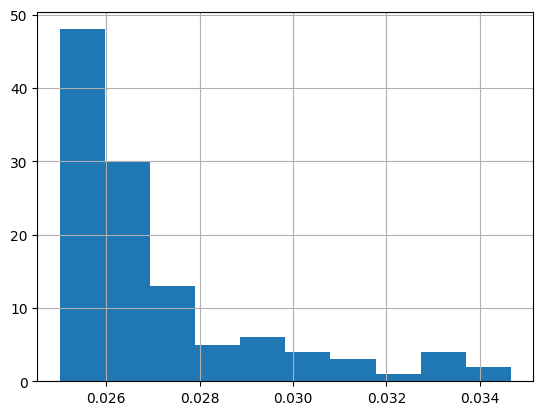

In [28]:
gdf_results[layer_id_era5].hist()

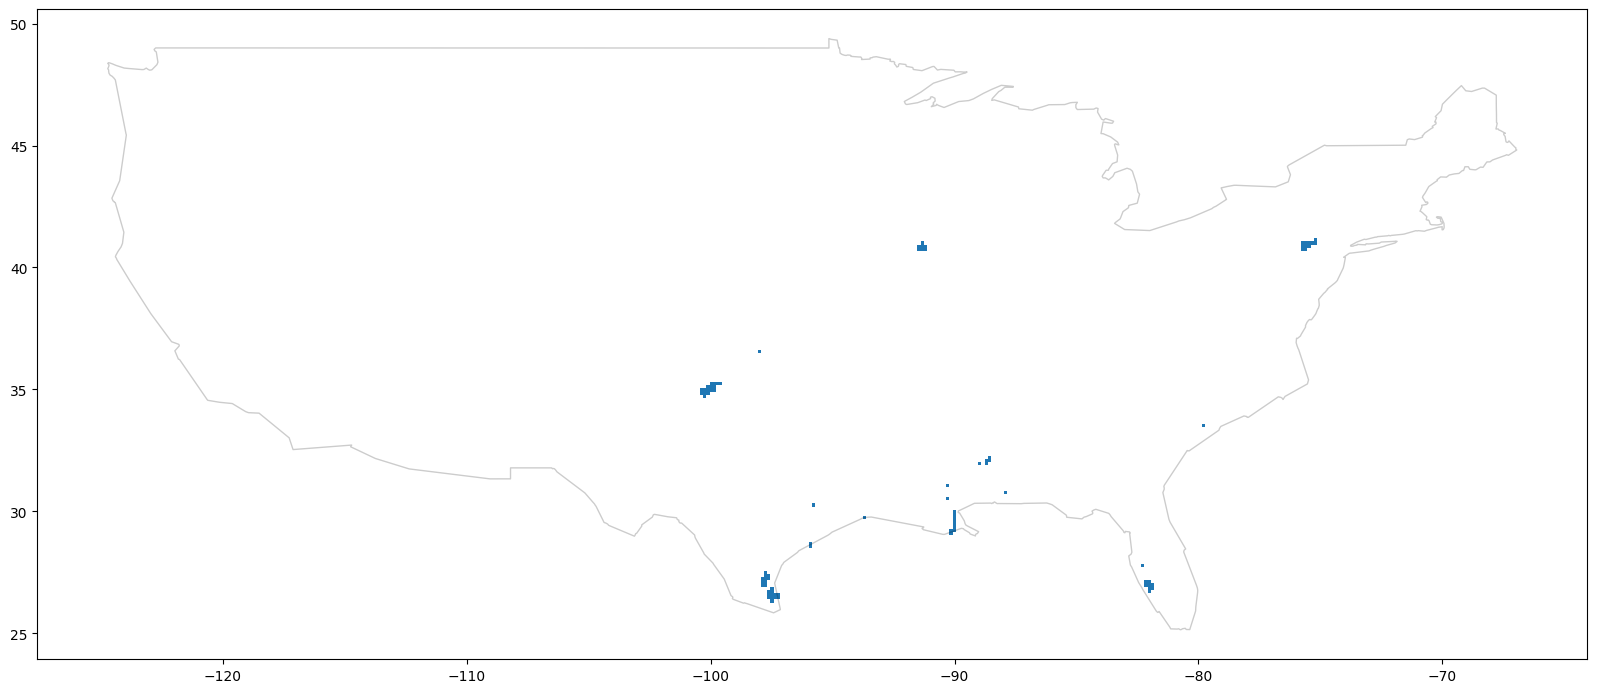

,timestamp,49459,q_key,geometry
0,2021-05-04 23:00:00,0.026442,0q003230310130,"POLYGON ((-88.90496 31.89696, -88.90496 32.028..."
1,2021-05-05 00:00:00,0.026446,0q003230311020,"POLYGON ((-88.64282 31.89696, -88.64282 32.028..."
2,2021-05-05 00:00:00,0.026788,0q003230311022,"POLYGON ((-88.64282 32.02803, -88.64282 32.159..."
3,2021-05-05 00:00:00,0.025590,0q003230311023,"POLYGON ((-88.51174 32.02803, -88.51174 32.159..."
4,2021-05-05 00:00:00,0.025350,0q003230311201,"POLYGON ((-88.51174 32.15910, -88.51174 32.290..."
...,...,...,...,...
111,2021-09-02 00:00:00,0.025560,0q003322211323,"POLYGON ((-75.40454 40.94093, -75.40454 41.072..."
112,2021-09-02 01:00:00,0.025295,0q003322211332,"POLYGON ((-75.27347 40.94093, -75.27347 41.072..."
113,2021-09-02 01:00:00,0.026643,0q003322211333,"POLYGON ((-75.14240 40.94093, -75.14240 41.072..."
114,2021-09-02 01:00:00,0.025232,0q003322213111,"POLYGON ((-75.14240 41.07200, -75.14240 41.203..."


In [29]:
ax = gdf_results.plot(figsize=(20,10))
gdf_valid_range = pd.DataFrame([{'geometry': query_polygon}])
gdf_valid_range = gpd.GeoDataFrame(gdf_valid_range, geometry='geometry')
gdf_valid_range.plot(ax=ax, color='none', edgecolor='black', alpha=0.2)
plt.show()

gdf_results = gdf_results.sort_values(by=['timestamp', 'q_key']).reset_index(drop=True)
gdf_results

## Conventional code

In [30]:
from typing import Union, Callable, Tuple
import xarray
def coarse_grain(data_array: xarray.DataArray, level: int, reducer: Union[str, Callable]='mean') -> xarray.DataArray:
    '''
    Reduces the spatial resolution of the data to match that of the new level.
    
    The data is assumed to be commensurate with the PAIRS grid. Recall that the PAIRS grid is anchored in the south west at the corner coordinate -90/-180 and that the resolution is 1e-6 * 2**(29-level) where level is an integer.
    
    Note that the data will be cropped such that the reduced, aggregated data is still commensurate with the PAIRS grid. That is, the function identifies the smallest crop leading to a valid raster.
    
    Args:
        data_array: Georeferenced data array as returned by dataservice.query.to_xarray. Has to be commensurate with the PAIRS grid.
        level: New resolution level of the data.
        reducer: Aggregation method. Possible values are max, median, mean, min, std, var as well as functions. If a function is provided, the function should accept a numpy array and return a single value. Example
        
        import functools, numpy
        reducer = functools.partial(numpy.quantile, q=0.99)
        coarse_grain(data_array, level, reducer)
        
    Returns:
        xarray data array which has the same dimensions as the original input yet size along the latitude and longitude dimensions is reduced by a factor of 2**(src_level-dst_level). Here, dst_level is the value of the level argument and src_level the value of the resolution_level key of data_array.
    '''
    supported_reducers = ['max', 'median', 'mean', 'min', 'std', 'var']
    
    src_data_array = data_array
    dst_level = level
    
    # Check arguments for validity
    if (reducer not in supported_reducers) and (not isinstance(reducer, Callable)):
        raise ValueError(
            f'Reducer {reducer} should either be a string or a callable. In the former case, possible values are {", ".join(supported_reducers)}.'
        )
    if not src_data_array.attrs.get('grid_type')=='pairs':
        raise ValueError(
            'coarse_grain is only implemented for data commensurate with the PAIRS grid. In detail this means that the xarray object should have attributes `"grid_type" : "pairs"` and `"resolution_level" : level"` for some integer `level`. In the case at hand, the key `"grid_type"` is either missig or has the wrong value.'
        )
    try:
        src_level = src_data_array.attrs['resolution_level']
    except KeyError:
        raise ValueError(
            'coarse_grain is only implemented for data commensurate with the PAIRS grid. In detail this means that the xarray object should have attributes `"grid_type" : "pairs"` and `"resolution_level" : level"` for some integer `level`. In the case at hand, the key `"resolution_level"` is missing.'
        )

    delta_level = src_level - dst_level
    if delta_level < 1:
        raise ValueError(
            f'The new level has to be smaller than the current resolution level of the data. However we have new: {dst_level}; old: {src_level}.'
        )
        
    # The problem with coarse-graining data is that in theory we might move to a grid that is not
    # the PAIRS grid at that resolution level. So we compute PAIRS xy coordinates
    # and subsequently find coordinates which perfectly align with coordinates at the new level.
    # As an aside, the lat/lon coordinates here are center of pixel. Yet since we are typecasting
    # this does not matter.
    # src_y = grid.lat_to_pairs_y(src_data_array.indexes['lat'].values, src_level).astype(numpy.int64)
    # src_x = grid.lon_to_pairs_x(src_data_array.indexes['lon'].values, src_level).astype(numpy.int64)
    src_y = morton.y_coord_to_idx(src_data_array.indexes['lat'].values, src_level).astype(numpy.int64)
    src_x = morton.x_coord_to_idx(src_data_array.indexes['lon'].values, src_level).astype(numpy.int64)
    assert numpy.all(numpy.diff(src_y)==-1) and numpy.all(numpy.diff(src_x)==1)
    
    try:
        x_0 = numpy.argwhere(src_x % 2**delta_level==0)[0, 0]
        x_1 = numpy.argwhere(src_x % 2**delta_level==2**delta_level-1)[-1, 0]
        y_0 = numpy.argwhere(src_y % 2**delta_level==2**delta_level-1)[0, 0]
        y_1 = numpy.argwhere(src_y % 2**delta_level==0)[-1, 0]
    except IndexError:
        raise ValueError(
            f'Insufficient data to reduce to level {level}. The raw data is of spatial size {src_data_array.coords["lat"].shape[0]} by {src_data_array.coords["lon"].shape[0]} (lat x lon). You are trying to reduce from level {src_level} to {dst_level}, which is a factor of {2**delta_level}.'
        )
    if (x_1 < x_0) or (y_1 < y_0):
        raise ValueError(
            f'Insufficient data to reduce to level {level}. The raw data is of spatial size {src_data_array.coords["lat"].shape[0]} by {src_data_array.coords["lon"].shape[0]} (lat x lon). You are trying to reduce from level {src_level} to {dst_level}, which is a factor of {2**delta_level}.'
        )
    
    # Technically we do not need this. We get the coorrect coordinates simply by coarsening
    #dst_x = (src_x[x_0:x_1+1]//2**delta_level)[::2**delta_level]
    #dst_y = (src_y[y_0:y_1+1]//2**delta_level)[::2**delta_level]
    
    # The actual coarsening is handled by xarray
    dst_data_array = src_data_array.isel(lon=slice(x_0, x_1+1), lat=slice(y_0, y_1+1)).coarsen(
        {
            'lat' : 2**delta_level,
            'lon' : 2**delta_level
        }
    ).reduce(reducer)
    # Per usual, we need to round the coordinates to escape any floating point issues
    dst_data_array = dst_data_array.assign_coords(
        {
            'lat' : dst_data_array.coords['lat'].round(9),
            'lon' : dst_data_array.coords['lon'].round(9)
        }
    )
    dst_data_array.attrs['resolution_level'] == dst_level
    
    return dst_data_array

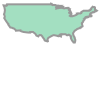

In [31]:
api_response = requests.get(
    'https://pairs.res.ibm.com/ws/queryaois/geojson/24',
    auth=geodn_auth
)
query_polygon = shapely.geometry.shape(
    geojson.loads(
        api_response.text.rstrip()[1:-1].replace('""', '"')
    )
)
query_polygon

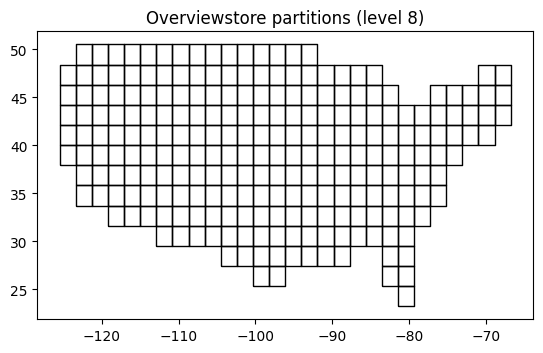

,q_key,geometry
0,0q00233033,"POLYGON ((-123.37690 33.73197, -123.37690 35.8..."
1,0q00233121,"POLYGON ((-119.18259 31.63482, -119.18259 33.7..."
2,0q00233122,"POLYGON ((-121.27974 33.73197, -121.27974 35.8..."
3,0q00233123,"POLYGON ((-119.18259 33.73197, -119.18259 35.8..."
4,0q00233130,"POLYGON ((-117.08544 31.63482, -117.08544 33.7..."
...,...,...
235,0q02110011,"POLYGON ((-73.04525 44.21773, -73.04525 46.314..."
236,0q02110100,"POLYGON ((-70.94810 44.21773, -70.94810 46.314..."
237,0q02110101,"POLYGON ((-68.85094 44.21773, -68.85094 46.314..."
238,0q02110102,"POLYGON ((-70.94810 46.31488, -70.94810 48.412..."


In [32]:
max_level_cropscape = raster_cropscape.spatial_level+4
qt_cropscape = qtree.QTree(query_polygon, max_level_cropscape)
gdf_partitions_cropscape = qt_cropscape.gridded_to_geodataframe(key_col=None, level_col=None)
gdf_partitions_cropscape.plot(color='none')
plt.title(f'Overviewstore partitions (level {max_level_cropscape})')
plt.show()
gdf_partitions_cropscape

In [33]:
timestamps_cropscape = dataservice.query.get_global_timestamps(
    layer_id_cropscape, datetime.datetime(year, 1, 1), datetime.datetime(year, 1, 1)
)
timestamps_era5 = dataservice.query.get_global_timestamps(
    layer_id_era5, datetime.datetime(year, 1, 1), datetime.datetime(year, 12, 31, 23, 59, 59)
)

In [34]:
conventional = time()

In [35]:
water_areas = []
for _, part_info in tqdm(gdf_partitions_cropscape.iterrows(), total=len(gdf_partitions_cropscape)):
    cropscape_raster = dataservice.query.to_xarray(
        layer_id_cropscape,
        pixel_level_cropscape,
        part_info['geometry'].exterior.bounds[1],
        part_info['geometry'].exterior.bounds[0],
        part_info['geometry'].exterior.bounds[3],
        part_info['geometry'].exterior.bounds[2],
        timestamps_cropscape
    )

    water_areas_raster = cropscape_raster==111
    if not water_areas_raster.any().item():
        continue
        
    # for k, v in cropscape_raster.attrs.items():
    #     water_areas_raster.attrs[k] = v
    # water_areas_raster = dataservice.util.raster.coarse_grain(water_areas_raster, pixel_level_era5, reducer=numpy.sum)
    water_areas_raster.attrs['grid_type'] = 'pairs'
    water_areas_raster.attrs['resolution_level'] = pixel_level_cropscape
    water_areas_raster = coarse_grain(water_areas_raster, pixel_level_era5, reducer=numpy.sum)
    water_areas_raster = water_areas_raster.isel(time=0).to_pandas().stack()
    water_areas.append(water_areas_raster.where(water_areas_raster>0).dropna())

100%|████████████████████████████████████████████████████████████| 240/240 [31:10<00:00,  7.79s/it]


In [36]:
water_areas = pd.concat(water_areas)
water_areas

lat        lon        
35.763584  -121.345280     351.0
35.632512  -121.345280     134.0
33.666432  -118.330624      10.0
           -118.199552      16.0
           -118.068480    3513.0
                           ...  
46.380416  -68.261120      838.0
           -68.130048      829.0
           -67.998976      836.0
           -67.867904     1038.0
           -67.736832       77.0
Length: 45221, dtype: float64

In [37]:
q_keys = morton.get_key(
    numpy.array(water_areas.reset_index()['lat']), 
    numpy.array(water_areas.reset_index()['lon']), 
    pixel_level_era5
)
q_keys = morton.encode(q_keys, [pixel_level_era5]*len(q_keys))
df = pd.DataFrame(morton.base4_to_box(q_keys), q_keys)
df = df.reset_index().rename(columns={'index': 'q_key', 0: 'geometry'})
gdf_water_areas = gpd.GeoDataFrame(df, geometry='geometry')
gdf_water_areas

,q_key,geometry
0,0q002330333333,"POLYGON ((-121.27974 35.69805, -121.27974 35.8..."
1,0q002330333331,"POLYGON ((-121.27974 35.56698, -121.27974 35.6..."
2,0q002331212332,"POLYGON ((-118.26509 33.60090, -118.26509 33.7..."
3,0q002331212333,"POLYGON ((-118.13402 33.60090, -118.13402 33.7..."
4,0q002331213222,"POLYGON ((-118.00294 33.60090, -118.00294 33.7..."
...,...,...
45216,0q021101030100,"POLYGON ((-68.19558 46.31488, -68.19558 46.445..."
45217,0q021101030101,"POLYGON ((-68.06451 46.31488, -68.06451 46.445..."
45218,0q021101030110,"POLYGON ((-67.93344 46.31488, -67.93344 46.445..."
45219,0q021101030111,"POLYGON ((-67.80237 46.31488, -67.80237 46.445..."


In [38]:
print(time() - conventional)

1872.433756828308


In [39]:
result_direct = []

def chunks(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]
        
timestamps = pd.date_range(f'{year}-01-01', f'{year}-12-31T23:59:59', freq='h')
timestamps = (
    (timestamps - pd.Timestamp('1970-01-01T00:00:00')) / pd.Timedelta('1s')
).astype(numpy.int64)

for timestamp_group in tqdm(chunks(timestamps, 96), total=len(timestamps)//96):
    era5_data = dataservice.query.to_xarray(
        layer_id_era5,
        pixel_level_era5,
        query_polygon.bounds[1]+epsilon,
        query_polygon.bounds[0]+epsilon,
        query_polygon.bounds[3]-epsilon,
        query_polygon.bounds[2]-epsilon,
        timestamp_group
    )
    result_direct.append(era5_data.where(era5_data > precip_threshold).to_dataframe()['49459'].dropna())
    
result_direct = pd.concat(
    result_direct, axis=0
)

92it [01:29,  1.03it/s]                                                                            


In [40]:
print(time() - conventional)

1962.2124433517456


In [41]:
q_keys = morton.get_key(
    numpy.array(result_direct.reset_index()['lat']), 
    numpy.array(result_direct.reset_index()['lon']), 
    pixel_level_era5
)
q_keys = morton.encode(q_keys, [pixel_level_era5]*len(q_keys))
df = pd.DataFrame(morton.base4_to_box(q_keys), [result_direct.reset_index()['time'], result_direct.reset_index()[layer_id_era5], q_keys])
df = df.reset_index().rename(columns={'time': 'timestamp', 'level_2': 'q_key', 0: 'geometry'})
gdf_results_direct = gpd.GeoDataFrame(df, geometry='geometry')

# Filtering
gdf_results_direct = gdf_results_direct[gdf_results_direct.intersects(query_polygon)].reset_index(drop=True)
gdf_results_direct = pd.merge(
    gdf_results_direct,
    gdf_water_areas[['q_key']].drop_duplicates(),
    on='q_key', how='inner'
).reset_index(drop=True)
gdf_results_direct

,timestamp,49459,q_key,geometry
0,2021-05-04 23:00:00,0.026442,0q003230310130,"POLYGON ((-88.90496 31.89696, -88.90496 32.028..."
1,2021-05-05 00:00:00,0.025350,0q003230311201,"POLYGON ((-88.51174 32.15910, -88.51174 32.290..."
2,2021-05-05 00:00:00,0.026788,0q003230311022,"POLYGON ((-88.64282 32.02803, -88.64282 32.159..."
3,2021-05-05 00:00:00,0.025590,0q003230311023,"POLYGON ((-88.51174 32.02803, -88.51174 32.159..."
4,2021-05-05 00:00:00,0.026446,0q003230311020,"POLYGON ((-88.64282 31.89696, -88.64282 32.028..."
...,...,...,...,...
111,2021-09-02 00:00:00,0.025817,0q003322211302,"POLYGON ((-75.53562 40.67878, -75.53562 40.809..."
112,2021-09-02 01:00:00,0.025232,0q003322213111,"POLYGON ((-75.14240 41.07200, -75.14240 41.203..."
113,2021-09-02 01:00:00,0.025295,0q003322211332,"POLYGON ((-75.27347 40.94093, -75.27347 41.072..."
114,2021-09-02 01:00:00,0.026643,0q003322211333,"POLYGON ((-75.14240 40.94093, -75.14240 41.072..."


In [42]:
print(time() - conventional)

1962.4813644886017


In [43]:
# Plotting

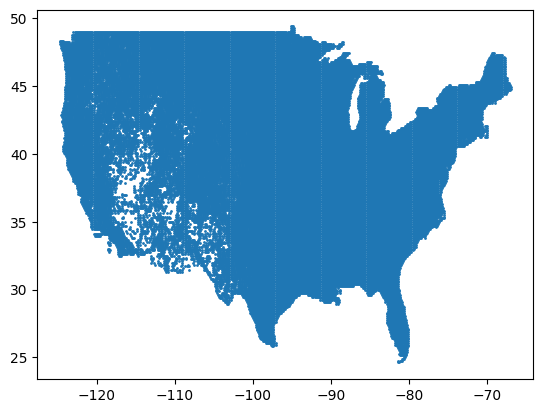

In [44]:
plt.scatter(
    water_areas.index.get_level_values('lon'),
    water_areas.index.get_level_values('lat'),
    s=1
)

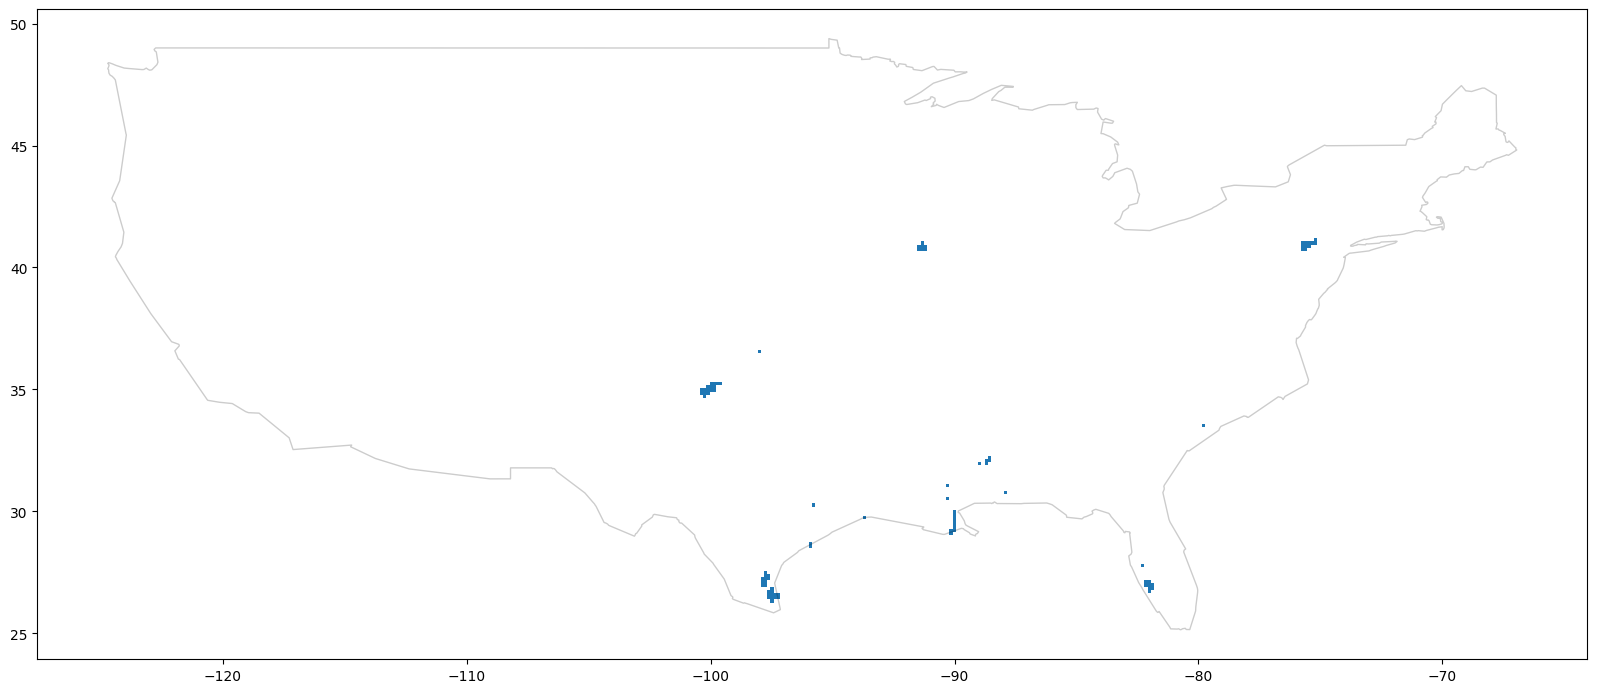

,timestamp,49459,q_key,geometry
0,2021-05-04 23:00:00,0.026442,0q003230310130,"POLYGON ((-88.90496 31.89696, -88.90496 32.028..."
1,2021-05-05 00:00:00,0.026446,0q003230311020,"POLYGON ((-88.64282 31.89696, -88.64282 32.028..."
2,2021-05-05 00:00:00,0.026788,0q003230311022,"POLYGON ((-88.64282 32.02803, -88.64282 32.159..."
3,2021-05-05 00:00:00,0.025590,0q003230311023,"POLYGON ((-88.51174 32.02803, -88.51174 32.159..."
4,2021-05-05 00:00:00,0.025350,0q003230311201,"POLYGON ((-88.51174 32.15910, -88.51174 32.290..."
...,...,...,...,...
111,2021-09-02 00:00:00,0.025560,0q003322211323,"POLYGON ((-75.40454 40.94093, -75.40454 41.072..."
112,2021-09-02 01:00:00,0.025295,0q003322211332,"POLYGON ((-75.27347 40.94093, -75.27347 41.072..."
113,2021-09-02 01:00:00,0.026643,0q003322211333,"POLYGON ((-75.14240 40.94093, -75.14240 41.072..."
114,2021-09-02 01:00:00,0.025232,0q003322213111,"POLYGON ((-75.14240 41.07200, -75.14240 41.203..."


In [45]:
ax = gdf_results_direct.plot(figsize=(20,10))
gdf_valid_range = pd.DataFrame([{'geometry': query_polygon}])
gdf_valid_range = gpd.GeoDataFrame(gdf_valid_range, geometry='geometry')
gdf_valid_range.plot(ax=ax, color='none', edgecolor='black', alpha=0.2)
plt.show()

gdf_results_direct = gdf_results_direct.sort_values(by=['timestamp', 'q_key']).reset_index(drop=True)
gdf_results_direct

In [48]:
(gdf_results_direct==gdf_results).all()

timestamp    True
49459        True
q_key        True
geometry     True
dtype: bool

In [50]:
print('acceleration', 1962/26)

acceleration 75.46153846153847
